In this project, a salary dataset has been taken from kaggle.

Link to the dataset: https://www.kaggle.com/datasets/rkiattisak/salaly-prediction-for-beginer 

The goal is to analyse the relation of salary with factors such as years of experience, education level, gender and age. 

# Data analysis

In [16]:
# Required libraries
import csv
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Read the csv file
data = pd.read_csv('Salary Data.csv')
data.head()


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [3]:
# Check for the missing entries
pd.isna(data).sum()
# Drop the missing entries
data.dropna(inplace=True)

In [8]:
# Convert the data type of columns 'Gender' and 'Years of Experience' to int
data['Age'] = data['Age'].astype(int)
data['Years of Experience'] = data['Years of Experience'].astype(int)

# Drop 'Job Title' column
data.drop('Job Title', axis=1, inplace=True)

In [9]:
# Categorise the columns 'Gender' and 'Education Level' using one-hot encoding
enc = OrdinalEncoder(categories=[["Bachelor's", "Master's", "PhD"]])
oh_enc = OneHotEncoder(drop='first', sparse_output=False)  # drop='first' to avoid dummy variable trap

# We'll do train-test split before encoding to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(data.drop('Salary', axis=1), data['Salary'], test_size=0.2, random_state=42)
enc.fit(X_train[['Education Level']])
X_train['Education Level'] = enc.transform(X_train[['Education Level']])
X_test['Education Level'] = enc.transform(X_test[['Education Level']])

X_train['Gender'] = oh_enc.fit_transform(X_train[['Gender']])
X_test['Gender'] = oh_enc.transform(X_test[['Gender']])

In [6]:
X_train.head()

,Age,Gender,Education Level,Job Title,Years of Experience
193,34,1.0,0.0,Senior Product Manager,7
75,37,1.0,0.0,Project Manager,10
84,29,0.0,0.0,Junior Designer,2
363,33,1.0,0.0,Junior Marketing Specialist,5
16,33,0.0,1.0,Marketing Manager,7


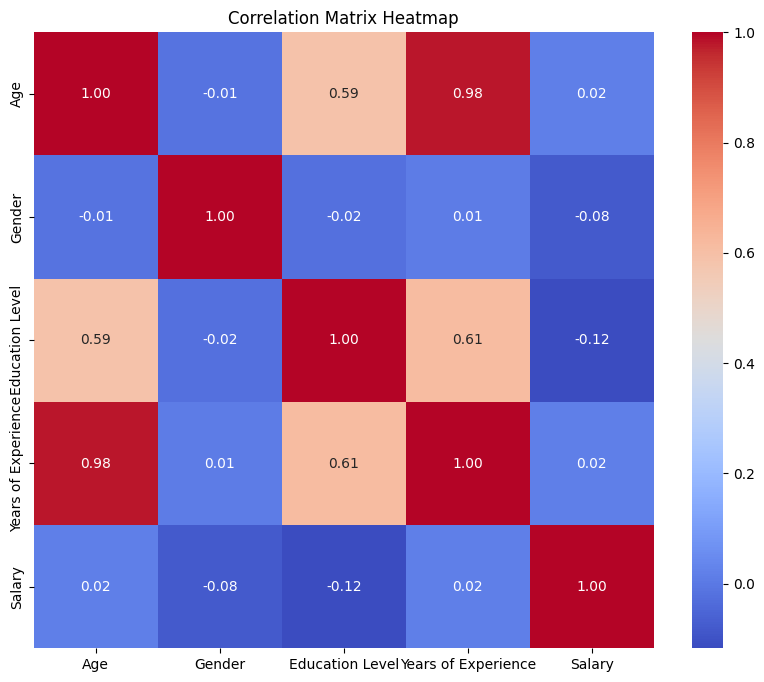

In [10]:
# We'll check the correlation between variables before applying linear regression
# Define data_new as the concatenation of X_train and X_test
data_new = X_train.copy()
data_new['Salary'] = y_train.reset_index(drop=True)  # Add the 'Salary' column from y_train
data_new.head()
#Calculate the correlation matrix
correlation_matrix = data_new.corr()
#Display the correlation matrix as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Linear Regression on 'Salary' column

In [18]:
# Make X_train and y_train as numpy arrays
X = X_train.values
y = y_train.values
# Add an extra column of 1s for intercept term
X = np.hstack((np.ones((X.shape[0], 1)), X))
# Calculate the coefficients using the normal equation
w = np.linalg.inv(X.T @ X) @ X.T @ y

# Next we'll make predictions on the test set
# Prepare the test set
test_matrix = X_test.values
test_matrix = np.hstack((np.ones((test_matrix.shape[0], 1)), test_matrix))
pred = test_matrix @ w
error = pred - y_test.values

# Calculate Mean Absolute Error
mae = np.mean(np.abs(error))
print(f'Mean Absolute Error: {mae}')


Mean Absolute Error: 10611.38705622342


In [22]:
# We'll also compare the weights calculated using the normal equation with the weights calculated using linear regression from sklearn
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print("Coefficients from Normal Equation:", w)
print("Intercept and Coefficients from Linear Regression:", model.intercept_, model.coef_)

Coefficients from Normal Equation: [-61174.92242781   3403.43221745   7569.07276133  14989.11679413
   2197.68864887]
Intercept and Coefficients from Linear Regression: -61174.922427813624 [ 3403.43221745  7569.07276133 14989.11679413  2197.68864887]


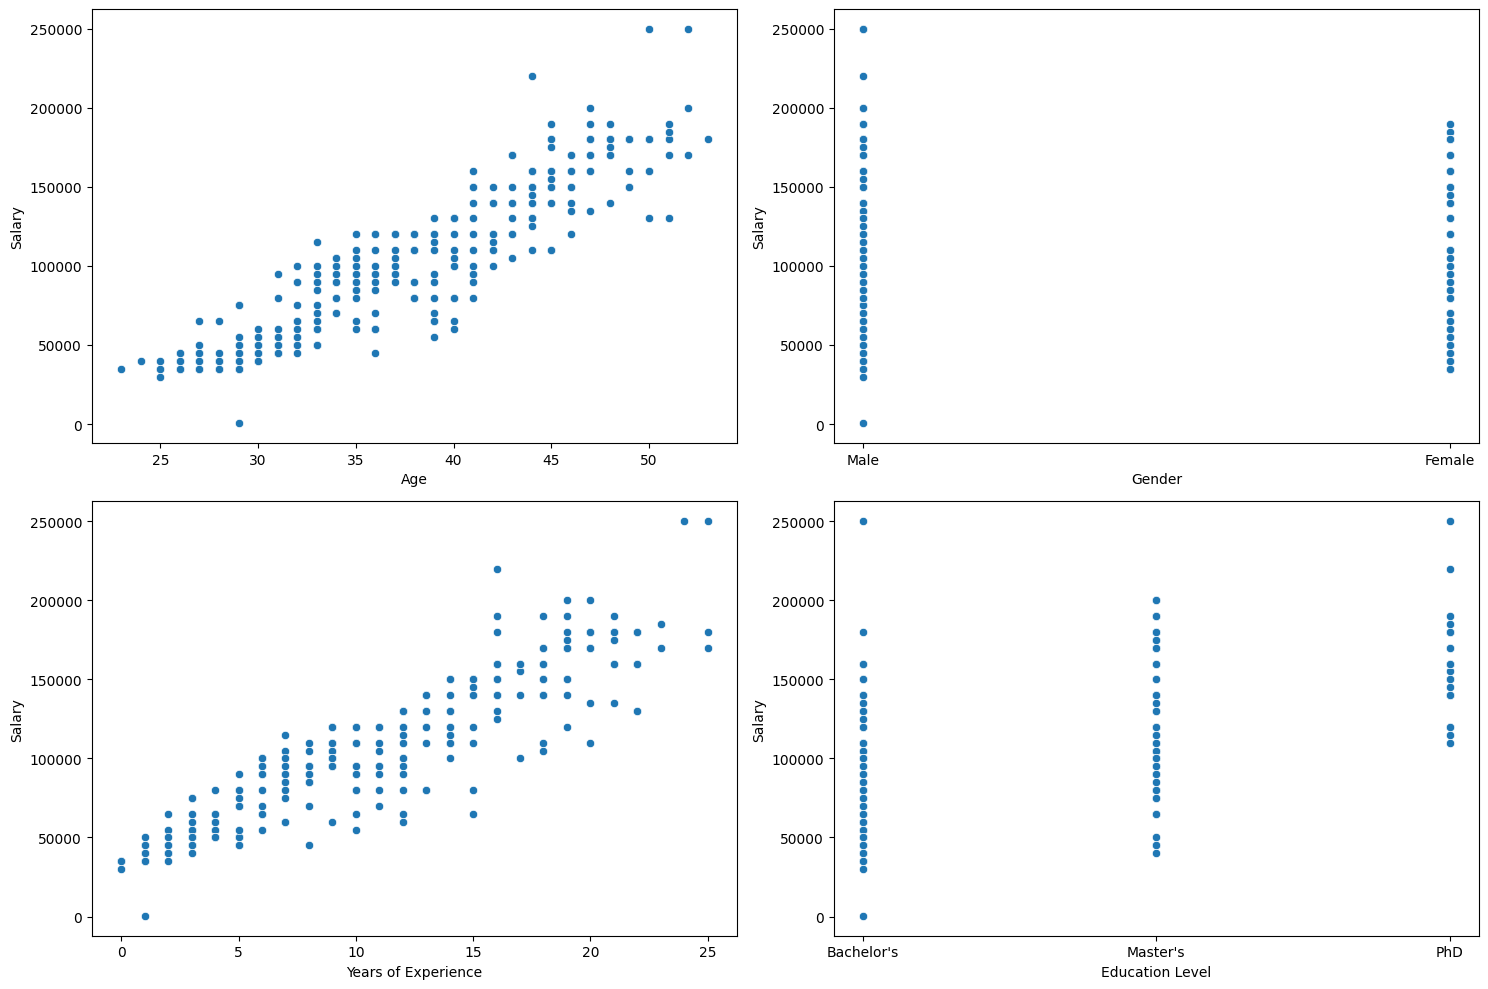

In [24]:
# We'll plot individually the salary as a function of Age, Gender, years of experience and Education Level to see the relationship between them
# Using subplots to plot multiple graphs
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Plot Salary vs Age
sns.scatterplot(x=data['Age'], y=data['Salary'], ax=axes[0, 0])
# Plot Salary vs gender
sns.scatterplot(x=data['Gender'], y=data['Salary'], ax=axes[0, 1])
# Plot Salary vs Years of Experience
sns.scatterplot(x=data['Years of Experience'], y=data['Salary'], ax=axes[1, 0])
# Plot Salary vs Education Level
sns.scatterplot(x=data['Education Level'], y=data['Salary'], ax=axes[1, 1])
plt.tight_layout()
plt.show()